## Business Analysis

### 1. Project Objective

The objective of this notebook is to answer key business questions using the cleaned retail sales dataset.

This notebook focuses on:

- Sales performance
- Profitability
- Product performance
- Customer behavior
- Regional performance
- Discount impact
- Shipping performance

The goal is to generate actionable business insights and recommendations.

### 2. Import Libraries

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


from src.loader import load_clean_data

# unify chart style
from src.visualization import set_plot_style
set_plot_style()

from src.visualization import plot_bar
from src.visualization import plot_histogram
from src.visualization import plot_line


In [6]:
# Reload module
import importlib
import src.visualization

importlib.reload(src.visualization)

<module 'src.visualization' from 'E:\\da_portfolio\\dap1_superstore_sales\\src\\visualization.py'>

### 3. Load Clean Dataset

In [2]:
df = load_clean_data("../data/processed/superstore_clean.csv")

df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Weekday,Shipping Days,Profit Margin
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,2013,11,November,4,Saturday,3,0.1600
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,2013,11,November,4,Saturday,3,0.3000
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,2013,6,June,2,Thursday,4,0.4700
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,2012,10,October,4,Thursday,7,-0.4000
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,2012,10,October,4,Thursday,7,0.1125


### 4. Sales Performance Analysis

Business Question:<br>

How has the company's sales performance changed over time?<br>

This section explores sales trends across different time periods to identify long-term growth patterns and seasonal fluctuations.

#### 4.1 Monthly Sales Trend

In [4]:
monthly_sales = (
    df
    .groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head(5)

,Order Date,Sales
0,2011-01-31,13946.229
1,2011-02-28,4810.558
2,2011-03-31,55691.009
3,2011-04-30,28295.345
4,2011-05-31,23648.287


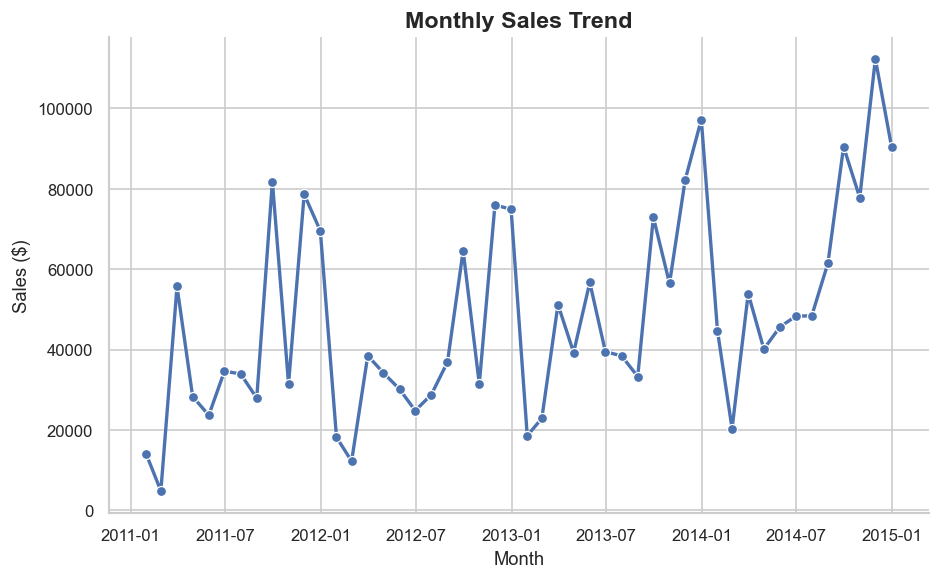

In [8]:
plot_line(
    monthly_sales,
    x="Order Date",
    y="Sales",
    title="Monthly Sales Trend",
    xlabel="Month",
    ylabel="Sales ($)"
)

Observation:<br>
- Monthly sales show an overall upward trend.
- Several sales peaks occur toward the end of each year.
- Sales fluctuate considerably from month to month.

### 5. Profit Analysis

Business Question:<br>

Is profit growing at the same pace as sales?<br>

This section investigates profit trends and profitability over time.